<a href="https://colab.research.google.com/github/tanuiivy/bbt4106-202604-D4-classification/blob/feature%2Fexplainability-Angela/bbt4106_202604_D4_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Invoice Payment Risk: A Classification Analysis of B2B Client Payment Behavior**

## 1. Setup & dependencies

In [4]:
#For resampling and `shap` for explainability.
!pip install -q imbalanced-learn shap

In [5]:
# Setup & Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
import urllib.request
import os


# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')

TARGET = 'payment_risk_category'

## 2. Data loading & exploratory data analysis

In [6]:
# Load the dataset
dataset_path = './data/invoice_payment_risk.csv'
url = 'https://raw.githubusercontent.com/tanuiivy/bbt4106-202604-D4-classification/refs/heads/main/invoice_payment_risk.csv'

if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    if not os.path.exists('./data'):
        os.makedirs('./data')
    urllib.request.urlretrieve(url, dataset_path)
    print("Dataset downloaded✅ ")
else:
    print("Dataset already exists locally✅ ")

invoice_data = pd.read_csv(dataset_path, encoding='utf-8')
print(f"Shape: {invoice_data.shape[0]} rows, {invoice_data.shape[1]} columns")
invoice_data.head()

Dataset downloaded✅ 
Shape: 1500 rows, 16 columns


,invoice_id,client_industry,client_credit_rating,client_company_size,payment_method,has_dispute_history,collateral_or_guarantee,payment_terms_days,invoice_amount_kes,client_relationship_years,prior_late_payments_count,discount_offered_pct,days_outstanding_avg_historical,guarantee_value_kes,economic_sector_growth_rate_pct,payment_risk_category
0,1,Technology,Good,Large,Bank Transfer,Yes,No,45,256337.0,1.9,1,2.73,22.2,NaN,4.87,Late
1,2,Manufacturing,Fair,Small,Bank Transfer,No,No,60,608908.0,6.8,1,2.10,34.0,NaN,2.09,On-Time
2,3,Technology,Good,Medium,Bank Transfer,Yes,No,15,499261.0,5.0,1,2.19,24.6,NaN,4.80,On-Time
3,4,Technology,Good,Medium,Mobile Money,No,No,15,219366.0,8.1,0,1.30,10.3,NaN,4.24,On-Time
4,5,Retail,Excellent,Large,Cheque,Yes,No,45,288282.0,4.5,0,3.26,12.9,NaN,1.42,On-Time


###2.1  Confirm column data types

In [7]:
invoice_data.dtypes

,0
invoice_id,int64
client_industry,object
client_credit_rating,object
client_company_size,object
payment_method,object
has_dispute_history,object
collateral_or_guarantee,object
payment_terms_days,int64
invoice_amount_kes,float64
client_relationship_years,float64


In [8]:
object_cols = invoice_data.select_dtypes(include='object').columns.tolist()
print(f"""
{len(object_cols)} columns are read as object (text) type: {object_cols}.
has_dispute_history and collateral_or_guarantee are Yes/No fields but load as text, not boolean,
because pandas does not auto-detect two-valued strings as booleans. These, along with the other
categorical columns, will need encoding before any model in section 5 can use them.
""")


7 columns are read as object (text) type: ['client_industry', 'client_credit_rating', 'client_company_size', 'payment_method', 'has_dispute_history', 'collateral_or_guarantee', 'payment_risk_category'].
has_dispute_history and collateral_or_guarantee are Yes/No fields but load as text, not boolean,
because pandas does not auto-detect two-valued strings as booleans. These, along with the other
categorical columns, will need encoding before any model in section 5 can use them.



###2.2 Check target class balance

In [9]:
invoice_data['payment_risk_category'].value_counts()

,count
payment_risk_category,
On-Time,975
Late,375
Severely Late,150


In [10]:
invoice_data['payment_risk_category'].value_counts(normalize=True) * 100

,proportion
payment_risk_category,
On-Time,65.0
Late,25.0
Severely Late,10.0


In [11]:
pct = invoice_data['payment_risk_category'].value_counts(normalize=True) * 100
majority_class = pct.idxmax()
minority_class = pct.idxmin()
print(f"""
{majority_class} is the largest class at {pct.max():.1f}% of invoices, while {minority_class}
is the smallest at {pct.min():.1f}%. This gap confirms payment_risk_category is imbalanced,
which is why the train/test split in section 3 needs to be stratified, and why cross-validation
in section 6 needs stratified k-fold rather than plain k-fold.
""")


On-Time is the largest class at 65.0% of invoices, while Severely Late
is the smallest at 10.0%. This gap confirms payment_risk_category is imbalanced,
which is why the train/test split in section 3 needs to be stratified, and why cross-validation
in section 6 needs stratified k-fold rather than plain k-fold.



###2.3 Check categorical frequencies

In [12]:
categorical_cols = ['client_industry', 'client_credit_rating', 'client_company_size',
                     'payment_method', 'has_dispute_history', 'collateral_or_guarantee']

for col in categorical_cols:
    print(f"\n{col}:")
    print(invoice_data[col].value_counts())


client_industry:
client_industry
Manufacturing    394
Retail           334
Technology       286
Construction     255
Healthcare       231
Name: count, dtype: int64

client_credit_rating:
client_credit_rating
Good         537
Fair         453
Excellent    319
Poor         191
Name: count, dtype: int64

client_company_size:
client_company_size
Medium        528
Small         467
Large         358
Enterprise    147
Name: count, dtype: int64

payment_method:
payment_method
Bank Transfer       694
Mobile Money        371
Letter of Credit    229
Cheque              206
Name: count, dtype: int64

has_dispute_history:
has_dispute_history
No     1238
Yes     262
Name: count, dtype: int64

collateral_or_guarantee:
collateral_or_guarantee
No     962
Yes    538
Name: count, dtype: int64


In [13]:
for col in categorical_cols:
    top_category = invoice_data[col].value_counts().idxmax()
    top_pct = invoice_data[col].value_counts(normalize=True).max() * 100
    print(f"{col}: {top_category} is the most common value, at {top_pct:.1f}% of rows.")

client_industry: Manufacturing is the most common value, at 26.3% of rows.
client_credit_rating: Good is the most common value, at 35.8% of rows.
client_company_size: Medium is the most common value, at 35.2% of rows.
payment_method: Bank Transfer is the most common value, at 46.3% of rows.
has_dispute_history: No is the most common value, at 82.5% of rows.
collateral_or_guarantee: No is the most common value, at 64.1% of rows.


In [14]:
numeric_cols = ['payment_terms_days', 'invoice_amount_kes', 'client_relationship_years',
                 'prior_late_payments_count', 'discount_offered_pct',
                 'days_outstanding_avg_historical', 'guarantee_value_kes',
                 'economic_sector_growth_rate_pct']

invoice_data[numeric_cols].describe()

,payment_terms_days,invoice_amount_kes,client_relationship_years,prior_late_payments_count,discount_offered_pct,days_outstanding_avg_historical,guarantee_value_kes,economic_sector_growth_rate_pct
count,1500.000000,1.500000e+03,1500.000000,1500.000000,1500.000000,1500.000000,5.380000e+02,1500.000000
mean,41.860000,3.627590e+05,5.833267,1.090000,2.030087,24.903600,2.898271e+05,2.326747
std,21.249504,2.534686e+05,4.062270,1.033414,1.145037,11.880925,2.245551e+05,1.316062
min,15.000000,1.000000e+04,0.200000,0.000000,0.000000,0.000000,1.178712e+04,-0.120000
25%,30.000000,1.841765e+05,2.900000,0.000000,1.170000,16.300000,1.405622e+05,1.310000
50%,45.000000,3.044655e+05,4.800000,1.000000,2.010000,23.550000,2.315444e+05,2.040000
75%,45.000000,4.768210e+05,7.800000,2.000000,2.782500,31.200000,3.870093e+05,3.150000
max,90.000000,1.991781e+06,25.000000,6.000000,5.550000,78.000000,1.487066e+06,5.460000


In [15]:
print(f"""
invoice_amount_kes ranges from KES {invoice_data['invoice_amount_kes'].min():,.0f}
to KES {invoice_data['invoice_amount_kes'].max():,.0f}, with a mean of
KES {invoice_data['invoice_amount_kes'].mean():,.0f} against a median of
KES {invoice_data['invoice_amount_kes'].median():,.0f}. The mean sitting above the median
is an early signal of right skew, checked formally in 2.4.
""")


invoice_amount_kes ranges from KES 10,000
to KES 1,991,781, with a mean of
KES 362,759 against a median of
KES 304,466. The mean sitting above the median
is an early signal of right skew, checked formally in 2.4.



###2.4 Compute numeric distribution measures

In [16]:
q1 = invoice_data[numeric_cols].quantile(0.25)
q2 = invoice_data[numeric_cols].quantile(0.50)
q3 = invoice_data[numeric_cols].quantile(0.75)
iqr = q3 - q1

distribution_summary = pd.DataFrame({
    'min': invoice_data[numeric_cols].min(),
    'q1_25%': q1,
    'q2_50%_median': q2,
    'q3_75%': q3,
    'max': invoice_data[numeric_cols].max(),
    'mean': invoice_data[numeric_cols].mean(),
    'mode': invoice_data[numeric_cols].mode().iloc[0],
    'variance': invoice_data[numeric_cols].var(),
    'std_dev': invoice_data[numeric_cols].std(),
    'skewness': invoice_data[numeric_cols].skew(),
    'kurtosis': invoice_data[numeric_cols].kurtosis(),
    'IQR': iqr,
    'lower_fence': q1 - 1.5 * iqr,
    'upper_fence': q3 + 1.5 * iqr,
})

distribution_summary.round(2)

,min,q1_25%,q2_50%_median,q3_75%,max,mean,mode,variance,std_dev,skewness,kurtosis,IQR,lower_fence,upper_fence
payment_terms_days,15.00,30.00,45.00,45.00,90.00,41.86,30.00,4.515400e+02,21.25,0.87,0.20,15.00,7.50,67.50
invoice_amount_kes,10000.00,184176.50,304465.50,476821.00,1991781.00,362759.00,10000.00,6.424634e+10,253468.62,1.49,3.29,292644.50,-254790.25,915787.75
client_relationship_years,0.20,2.90,4.80,7.80,25.00,5.83,3.90,1.650000e+01,4.06,1.41,2.71,4.90,-4.45,15.15
prior_late_payments_count,0.00,0.00,1.00,2.00,6.00,1.09,1.00,1.070000e+00,1.03,1.01,1.07,2.00,-3.00,5.00
discount_offered_pct,0.00,1.17,2.01,2.78,5.55,2.03,0.00,1.310000e+00,1.15,0.22,-0.42,1.61,-1.25,5.20
days_outstanding_avg_historical,0.00,16.30,23.55,31.20,78.00,24.90,21.10,1.411600e+02,11.88,0.85,1.09,14.90,-6.05,53.55
guarantee_value_kes,11787.12,140562.20,231544.36,387009.33,1487066.36,289827.08,11787.12,5.042498e+10,224555.08,1.70,3.81,246447.12,-229108.48,756680.01
economic_sector_growth_rate_pct,-0.12,1.31,2.04,3.15,5.46,2.33,1.53,1.730000e+00,1.32,0.57,-0.69,1.84,-1.45,5.91


In [17]:
outlier_mask = (
    (invoice_data[numeric_cols] < (q1 - 1.5 * iqr)) |
    (invoice_data[numeric_cols] > (q3 + 1.5 * iqr))
)

outlier_counts = outlier_mask.sum().rename('outlier_count').to_frame()
outlier_counts

,outlier_count
payment_terms_days,151
invoice_amount_kes,58
client_relationship_years,47
prior_late_payments_count,1
discount_offered_pct,5
days_outstanding_avg_historical,35
guarantee_value_kes,26
economic_sector_growth_rate_pct,0


In [18]:
most_skewed = distribution_summary['skewness'].abs().idxmax()
most_outliers = outlier_counts['outlier_count'].idxmax()

print(f"""
{most_skewed} is the most skewed numeric column (skewness = {distribution_summary.loc[most_skewed, 'skewness']:.2f}),
consistent with its mean (KES {distribution_summary.loc[most_skewed, 'mean']:,.0f}) sitting above
its median (KES {distribution_summary.loc[most_skewed, 'q2_50%_median']:,.0f}).

{most_outliers} has the most flagged outliers under the 1.5x IQR rule, at
{outlier_counts.loc[most_outliers, 'outlier_count']} rows. This is misleading rather than a data
quality concern: payment_terms_days only takes a small set of fixed values (15, 30, 45, 60, 90),
so the IQR fence is reacting to a common discrete tier, not a genuine anomaly. The remaining
flagged columns (invoice_amount_kes, client_relationship_years, days_outstanding_avg_historical,
guarantee_value_kes) are more meaningful outlier candidates, since they're genuinely continuous,
and warrant inspection rather than automatic removal in section 5.
""")


guarantee_value_kes is the most skewed numeric column (skewness = 1.70),
consistent with its mean (KES 289,827) sitting above
its median (KES 231,544).

payment_terms_days has the most flagged outliers under the 1.5x IQR rule, at
151 rows. This is misleading rather than a data
quality concern: payment_terms_days only takes a small set of fixed values (15, 30, 45, 60, 90),
so the IQR fence is reacting to a common discrete tier, not a genuine anomaly. The remaining
flagged columns (invoice_amount_kes, client_relationship_years, days_outstanding_avg_historical,
guarantee_value_kes) are more meaningful outlier candidates, since they're genuinely continuous,
and warrant inspection rather than automatic removal in section 5.



###2.5 Check missingness

In [19]:
invoice_data.isnull().sum()

,0
invoice_id,0
client_industry,0
client_credit_rating,0
client_company_size,0
payment_method,0
has_dispute_history,0
collateral_or_guarantee,0
payment_terms_days,0
invoice_amount_kes,0
client_relationship_years,0


In [20]:
missing_guarantee = invoice_data['guarantee_value_kes'].isnull().sum()
no_collateral = (invoice_data['collateral_or_guarantee'] == 'No').sum()
print(f"""
guarantee_value_kes is missing in {missing_guarantee} of {len(invoice_data)} rows
({missing_guarantee / len(invoice_data) * 100:.1f}%). This matches the {no_collateral} rows
where collateral_or_guarantee is No — the value is absent because there is no guarantee to
report, not because of a data collection failure. This is structural missingness, not random
missingness, and needs to be imputed differently from any genuinely random gaps in section 5.
""")


guarantee_value_kes is missing in 962 of 1500 rows
(64.1%). This matches the 962 rows
where collateral_or_guarantee is No — the value is absent because there is no guarantee to
report, not because of a data collection failure. This is structural missingness, not random
missingness, and needs to be imputed differently from any genuinely random gaps in section 5.



###2.6 Measures of relationship

In [21]:
from sklearn.feature_selection import f_classif

numeric_predictors_filled = invoice_data[numeric_cols].fillna(invoice_data[numeric_cols].median())

f_stats, p_values = f_classif(numeric_predictors_filled, invoice_data[TARGET])
anova_summary = pd.DataFrame({
    'feature': numeric_cols,
    'F_statistic': f_stats,
    'p_value': p_values
}).sort_values('F_statistic', ascending=False)

anova_summary.round(4)

,feature,F_statistic,p_value
0,payment_terms_days,148.4225,0.0000
3,prior_late_payments_count,70.1130,0.0000
5,days_outstanding_avg_historical,60.3109,0.0000
7,economic_sector_growth_rate_pct,15.8523,0.0000
4,discount_offered_pct,1.2006,0.3013
6,guarantee_value_kes,1.0433,0.3525
1,invoice_amount_kes,0.1485,0.8620
2,client_relationship_years,0.0992,0.9055


In [22]:
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corrected / min(k_corrected - 1, r_corrected - 1))

cramers_v_results = {}
for col in categorical_cols:
    contingency = pd.crosstab(invoice_data[col], invoice_data[TARGET])
    cramers_v_results[col] = cramers_v(contingency.values)

cramers_v_summary = pd.DataFrame({
    'feature': list(cramers_v_results.keys()),
    'cramers_v': list(cramers_v_results.values())
}).sort_values('cramers_v', ascending=False)

cramers_v_summary.round(4)

,feature,cramers_v
1,client_credit_rating,0.2873
4,has_dispute_history,0.1921
0,client_industry,0.1171
3,payment_method,0.0469
2,client_company_size,0.0185
5,collateral_or_guarantee,0.0166


`client_credit_rating` shows the strongest categorical association with `payment_risk_category`
(Cramer's V = 0.287), which falls in the moderate range (0.20-0.40), meaning a client's credit
rating carries real information about their payment risk. `has_dispute_history` follows at 0.192
(weak association), and `client_industry` at 0.117. `payment_method`, `client_company_size`, and
`collateral_or_guarantee` all fall below 0.05, showing negligible association with risk category
on their own.

Among numeric predictors, `payment_terms_days` shows by far the strongest relationship with the
target (F-statistic = 148.42, p < 0.001), followed by `prior_late_payments_count` (F = 70.11)
and `days_outstanding_avg_historical` (F = 60.31), both significant at p < 0.001. This is
consistent with the hypothesis in 2.7 that payment history drives risk more than invoice-specific
details. `economic_sector_growth_rate_pct` is also significant (F = 15.85), though weaker. Four
features, `discount_offered_pct`, `guarantee_value_kes`, `invoice_amount_kes`, and
`client_relationship_years`, show p-values well above 0.05, meaning no evidence of a linear,
mean-based relationship with risk category in isolation. This does not rule them out entirely:
ANOVA only detects linear separation, so section 4's mutual information check may still surface
non-linear relationships these results miss.


### 2.7 Hypothesis

Based on the measures of relationship in 2.6, `payment_terms_days`, `prior_late_payments_count`,
and `days_outstanding_avg_historical` are expected to be the strongest predictors of
`payment_risk_category`, given their high ANOVA F-statistics (148.42, 70.11, and 60.31
respectively, all p < 0.001). Among categorical features, `client_credit_rating` (Cramer's V =
0.287) is expected to contribute the most, with `has_dispute_history` (0.192) as a secondary
signal.

This revises an earlier assumption that payment history alone would dominate: `payment_terms_days`
— an invoice-specific term set at issuance, not part of a client's payment track record — shows
the strongest relationship of any single feature. `client_relationship_years`, despite intuitively
seeming like a track-record signal, shows no meaningful relationship with risk category
(F = 0.10, p = 0.91) and is not expected to contribute much on its own. This is tested formally
in section 6.

## 3. Train/test split

#### 3.1 The split

In [23]:
# payment_risk_category is imbalanced (Severely Late is the minority class, confirmed in 2.2).
# A plain random split risks leaving too few Severely Late invoices in the test set to evaluate
# properly. Stratifying directly on the target ensures both sets keep the same class proportions.

X = invoice_data.drop(columns=['invoice_id', TARGET])
y = invoice_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 1200 rows
Test set: 300 rows


In [24]:
train_pct = y_train.value_counts(normalize=True) * 100
test_pct = y_test.value_counts(normalize=True) * 100

split_check = pd.DataFrame({'train_%': train_pct, 'test_%': test_pct}).round(1)
print(split_check)


                       train_%  test_%
payment_risk_category                 
On-Time                   65.0    65.0
Late                      25.0    25.0
Severely Late             10.0    10.0


In [25]:
print(f"""
An 80/20 split was used given the dataset's size (1,500 rows) — large enough to hold out 20%
({X_test.shape[0]} rows) while still leaving {X_train.shape[0]} rows to train on. The table above
confirms stratification worked as intended: train and test class percentages are close to identical
for On-Time, Late, and Severely Late, so the minority class is represented in both sets rather than
concentrated in one.
""")


An 80/20 split was used given the dataset's size (1,500 rows) — large enough to hold out 20%
(300 rows) while still leaving 1200 rows to train on. The table above
confirms stratification worked as intended: train and test class percentages are close to identical
for On-Time, Late, and Severely Late, so the minority class is represented in both sets rather than
concentrated in one.



## 4. Feature selection

### 4.1 Recompute Measures of Relationship

In [26]:
from scipy import stats

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corrected / min(k_corrected - 1, r_corrected - 1))

numeric_train_filled = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
f_stats, p_values = f_classif(numeric_train_filled, y_train)
anova_train = pd.DataFrame({'feature': numeric_cols, 'F_statistic': f_stats, 'p_value': p_values}).sort_values('F_statistic', ascending=False)

cv_results = {col: cramers_v(pd.crosstab(X_train[col], y_train).values) for col in categorical_cols}
cramers_v_train = pd.DataFrame({'feature': list(cv_results.keys()), 'cramers_v': list(cv_results.values())}).sort_values('cramers_v', ascending=False)

print(anova_train.round(4))
print(cramers_v_train.round(4))

                           feature  F_statistic  p_value
0               payment_terms_days     130.6676   0.0000
3        prior_late_payments_count      46.2212   0.0000
5  days_outstanding_avg_historical      37.6530   0.0000
7  economic_sector_growth_rate_pct      10.5455   0.0000
4             discount_offered_pct       2.2857   0.1021
6              guarantee_value_kes       0.9681   0.3801
1               invoice_amount_kes       0.4884   0.6137
2        client_relationship_years       0.4454   0.6407
                   feature  cramers_v
1     client_credit_rating     0.2750
4      has_dispute_history     0.1897
0          client_industry     0.1044
3           payment_method     0.0596
5  collateral_or_guarantee     0.0288
2      client_company_size     0.0204


### 4.2 Mutual Information Check

In [27]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

mi_numeric = mutual_info_classif(numeric_train_filled, y_train, random_state=42)
mi_numeric_df = pd.DataFrame({'feature': numeric_cols, 'mutual_info': mi_numeric}).sort_values('mutual_info', ascending=False)

cat_train_encoded = X_train[categorical_cols].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
mi_categorical = mutual_info_classif(cat_train_encoded, y_train, discrete_features=True, random_state=42)
mi_categorical_df = pd.DataFrame({'feature': categorical_cols, 'mutual_info': mi_categorical}).sort_values('mutual_info', ascending=False)

print(mi_numeric_df.round(4))
print(mi_categorical_df.round(4))

                           feature  mutual_info
0               payment_terms_days       0.1016
3        prior_late_payments_count       0.0762
1               invoice_amount_kes       0.0132
4             discount_offered_pct       0.0065
5  days_outstanding_avg_historical       0.0032
2        client_relationship_years       0.0000
6              guarantee_value_kes       0.0000
7  economic_sector_growth_rate_pct       0.0000
                   feature  mutual_info
1     client_credit_rating       0.0799
4      has_dispute_history       0.0170
0          client_industry       0.0141
3           payment_method       0.0058
2      client_company_size       0.0029
5  collateral_or_guarantee       0.0013


### 4.3 Selected Features and Rationale

In [28]:
columns_to_drop = ['client_relationship_years', 'guarantee_value_kes',
                    'client_company_size', 'collateral_or_guarantee']

selected_numeric_features = [c for c in numeric_cols if c not in columns_to_drop]
selected_categorical_features = [c for c in categorical_cols if c not in columns_to_drop]

X_train_sel = X_train.drop(columns=columns_to_drop)
X_test_sel = X_test.drop(columns=columns_to_drop)

print(f"""
Two feature selection methods were applied to X_train/y_train only:
1. ANOVA F-test + Cramer's V (recomputed train-only in 4.1)
2. Mutual Information (4.2)

Four features are dropped on convergent evidence from both methods:
- client_relationship_years: not significant by ANOVA (p=0.64), MI=0.0000
- guarantee_value_kes: not significant by ANOVA (p=0.38), MI=0.0000, AND missing in
  {X_train['guarantee_value_kes'].isna().sum()} of {len(X_train)} training rows (63.5%),
  imputing a majority-missing column would mean the model leans on a placeholder value most
  of the time. Its information is already captured by collateral_or_guarantee (missingness
  matches that column's 'No' rows exactly), making it doubly redundant.
- client_company_size: Cramer's V=0.020, MI=0.0029 which is negligible by both measures
- collateral_or_guarantee: Cramer's V=0.029, MI=0.0013 which is negligible by both measures; the
  underlying "has collateral" signal turns out to be weak for predicting payment risk in
  this dataset, not just the numeric guarantee amount

Final feature set: {len(selected_numeric_features)} numeric + {len(selected_categorical_features)}
categorical = {len(selected_numeric_features)+len(selected_categorical_features)} features,
down from {len(numeric_cols)+len(categorical_cols)} original.
""")


Two feature selection methods were applied to X_train/y_train only:
1. ANOVA F-test + Cramer's V (recomputed train-only in 4.1)
2. Mutual Information (4.2)

Four features are dropped on convergent evidence from both methods:
- client_relationship_years: not significant by ANOVA (p=0.64), MI=0.0000
- guarantee_value_kes: not significant by ANOVA (p=0.38), MI=0.0000, AND missing in
  762 of 1200 training rows (63.5%),
  imputing a majority-missing column would mean the model leans on a placeholder value most
  of the time. Its information is already captured by collateral_or_guarantee (missingness
  matches that column's 'No' rows exactly), making it doubly redundant.
- client_company_size: Cramer's V=0.020, MI=0.0029 which is negligible by both measures
- collateral_or_guarantee: Cramer's V=0.029, MI=0.0013 which is negligible by both measures; the
  underlying "has collateral" signal turns out to be weak for predicting payment risk in
  this dataset, not just the numeric guarantee amo

## 5. Preprocessing pipeline

### 5.1 Handling Missingness

In [29]:
print(X_train_sel.isna().sum())

client_industry                    0
client_credit_rating               0
payment_method                     0
has_dispute_history                0
payment_terms_days                 0
invoice_amount_kes                 0
prior_late_payments_count          0
discount_offered_pct               0
days_outstanding_avg_historical    0
economic_sector_growth_rate_pct    0
dtype: int64


Zero missing values remain in the selected feature set. The only column with missingness in this dataset (guarantee_value_kes), was dropped in 4.3 for weak predictive evidence, which incidentally also resolved the dataset's only missingness problem.

### 5.2 Encoding and Scaling

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer

general_numeric = ['payment_terms_days', 'prior_late_payments_count', 'discount_offered_pct',
                    'days_outstanding_avg_historical', 'economic_sector_growth_rate_pct']
skewed_numeric = ['invoice_amount_kes']
nominal_categorical = ['client_industry', 'payment_method', 'has_dispute_history']
ordinal_categorical = ['client_credit_rating']

preprocessor = ColumnTransformer(transformers=[
    ('num_general', Pipeline([
        ('impute', SimpleImputer(strategy='median')),   # safety net; nothing missing here currently
        ('scale', StandardScaler())
    ]), general_numeric),

    ('num_skewed', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('transform', PowerTransformer(method='yeo-johnson', standardize=True))
    ]), skewed_numeric),

    ('cat_nominal', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
    ]), nominal_categorical),

    ('cat_ordinal', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(categories=[['Poor', 'Fair', 'Good', 'Excellent']]))
    ]), ordinal_categorical),
])

preprocessor.fit(X_train_sel, y_train)
print("Preprocessor fitted on training data only.")

Preprocessor fitted on training data only.


### 5.3 Skew Correction for numeriic Predictors

invoice_amount_kes                 1.523486
prior_late_payments_count          0.995760
payment_terms_days                 0.876251
days_outstanding_avg_historical    0.856842
economic_sector_growth_rate_pct    0.588661
discount_offered_pct               0.208049
dtype: float64


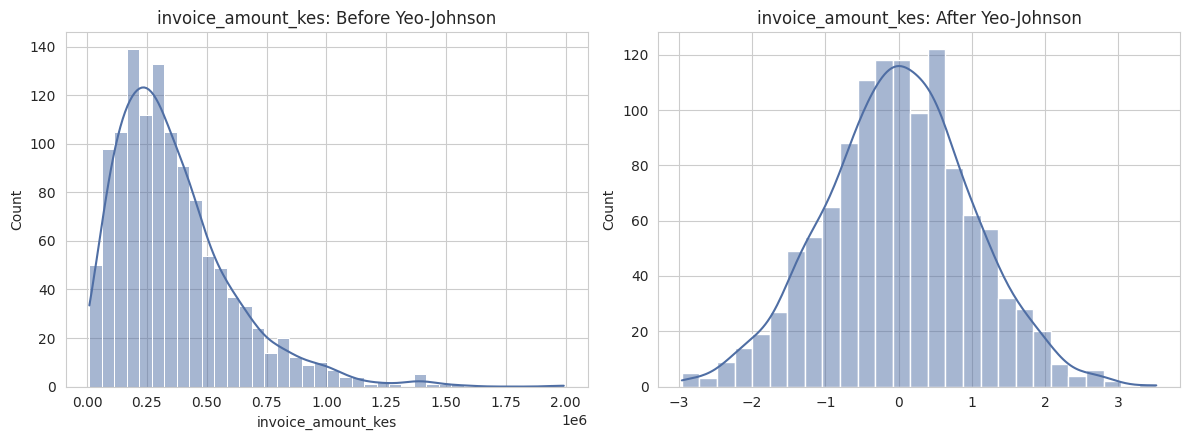

In [31]:
from scipy import stats

print(X_train_sel[general_numeric + skewed_numeric].skew().sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(X_train_sel['invoice_amount_kes'], kde=True, ax=axes[0], color='#4F6EA4')
axes[0].set_title('invoice_amount_kes: Before Yeo-Johnson')
transformed_preview = PowerTransformer(method='yeo-johnson').fit_transform(X_train_sel[['invoice_amount_kes']])
sns.histplot(transformed_preview.flatten(), kde=True, ax=axes[1], color='#4F6EA4')
axes[1].set_title('invoice_amount_kes: After Yeo-Johnson')
plt.tight_layout()
plt.show()

invoice_amount_kes (skew 1.52) is the most skewed surviving feature. Yeo-Johnson is chosen over Box-Cox since it also handles zero/negative values, a safer default even though this column is positive-only

## 6. Modeling & cross-validation

### 6.1 Candidate Models

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
}

# 5-fold cross-validation which is stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']

In [33]:
print(f"""
Section 6.1 compares six different models based on the following scores: accuracy, f1 macro, f1 weighted, precision macro and recall macro.
""")


Section 6.1 compares six different models based on the following scores: accuracy, f1 macro, f1 weighted, precision macro and recall macro.



## 6.2 Stratified k-fold cross validation results across all models

In [34]:
rows = []
for name, model in candidate_models.items():
    pipe = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    scores = cross_validate(pipe, X_train_sel, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'model': name}
    for metric in scoring:
        row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'{metric}_std'] = scores[f'test_{metric}'].std()
    rows.append(row)

# Arrange the models from the first to the last based on F1 macro score
results_df = pd.DataFrame(rows).sort_values('f1_macro_mean', ascending=False).reset_index(drop=True)
results_df.round(4)

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std
0,Logistic Regression,0.6983,0.0354,0.6258,0.0472,0.7112,0.0336,0.6067,0.0487,0.6716,0.0409
1,Random Forest,0.7117,0.0116,0.5996,0.0202,0.7042,0.0105,0.6257,0.0283,0.5848,0.0228
2,Support Vector Machine,0.6892,0.0176,0.5986,0.0235,0.7015,0.0173,0.5880,0.0284,0.6223,0.0160
3,Gradient Boosting,0.6958,0.0160,0.5805,0.0291,0.6946,0.0164,0.5874,0.0420,0.5790,0.0231
4,K-Nearest Neighbors,0.5858,0.0218,0.5049,0.0198,0.6119,0.0212,0.5024,0.0177,0.5372,0.0221
5,Decision Tree,0.6283,0.0194,0.4947,0.0320,0.6339,0.0204,0.4942,0.0278,0.5000,0.0373


In [35]:
print(f"""
The model with the best F1 macro score is Logistic Regression, with a score of 0.6258.
F1 macro score is best to use because it treats all the three classes (On Time, Late, Severely Late) as equally important.

""")


The model with the best F1 macro score is Logistic Regression, with a score of 0.6258.
F1 macro score is best to use because it treats all the three classes (On Time, Late, Severely Late) as equally important.




## 6.3 Chart showing comparison of all candidate models

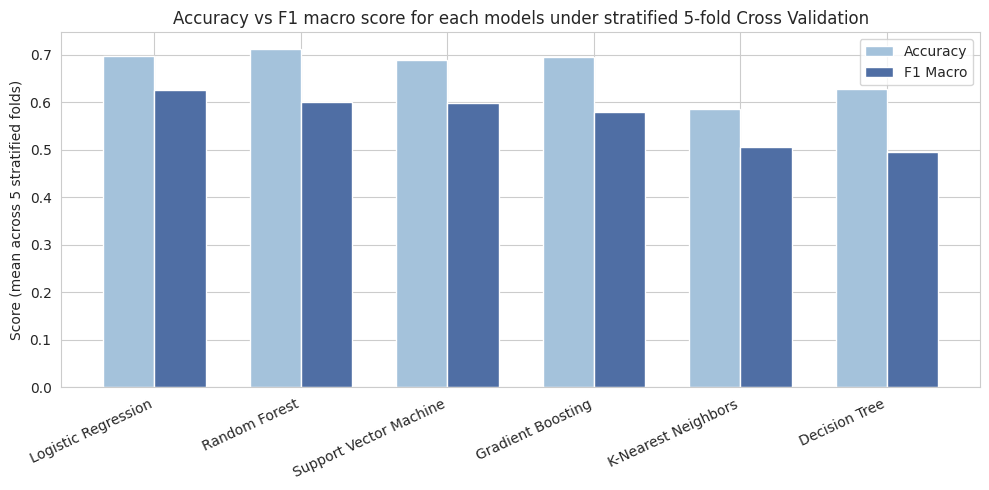

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

# Two bars are placed in a way that accuracy sits next to F1 macro for each model.
ax.bar(x - width/2, results_df['accuracy_mean'], width, label='Accuracy', color='#A4C2DB')
ax.bar(x + width/2, results_df['f1_macro_mean'], width, label='F1 Macro', color='#4F6EA4')
ax.set_xticks(x)

ax.set_xticklabels(results_df['model'], rotation=25, ha='right')
ax.set_ylabel('Score (mean across 5 stratified folds)')
ax.set_title('Accuracy vs F1 macro score for each models under stratified 5-fold Cross Validation')
ax.legend()
plt.tight_layout()
plt.show()

## 6.4 Select the model to carry into Hyperparameter Tuning

In [37]:
# Checks the top 2 models and how well they catch the Severely Late invoices
top_two = results_df.head(2)['model'].tolist()
reports = {}

for name in top_two:
    pipe = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', candidate_models[name])
    ])
    preds = cross_val_predict(pipe, X_train_sel, y_train, cv=cv)
    print(f"{name}")
    print(classification_report(y_train, preds, digits=3))
    reports[name] = classification_report(y_train, preds, output_dict=True)

Logistic Regression
               precision    recall  f1-score   support

         Late      0.452     0.520     0.484       300
      On-Time      0.891     0.762     0.821       780
Severely Late      0.468     0.733     0.571       120

     accuracy                          0.698      1200
    macro avg      0.604     0.672     0.625      1200
 weighted avg      0.739     0.698     0.712      1200

Random Forest
               precision    recall  f1-score   support

         Late      0.466     0.430     0.447       300
      On-Time      0.807     0.858     0.832       780
Severely Late      0.596     0.467     0.523       120

     accuracy                          0.712      1200
    macro avg      0.623     0.585     0.601      1200
 weighted avg      0.701     0.712     0.705      1200



In [38]:
print(f"""
Logistic Regression is the chosen model. It has the best F1 score of 0.6258 of all the models that were tested in section 6.2.
It also catches 73.3% of invoices that are actually Severely Late and this is better than Random Forest which catches 46.7% of the invoices.
""")


Logistic Regression is the chosen model. It has the best F1 score of 0.6258 of all the models that were tested in section 6.2.
It also catches 73.3% of invoices that are actually Severely Late and this is better than Random Forest which catches 46.7% of the invoices.



## 7. Diagnostics

In [39]:
# ============================================================
# 7.1 Fit the selected model on the training data
# ============================================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Use the model selected during cross-validation
selected_model_name = results_df.iloc[0]["model"]
selected_model = candidate_models[selected_model_name]

selected_pipe = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", selected_model)
])

# Fit ONLY on the training data
selected_pipe.fit(X_train_sel, y_train)

# Predictions on the held-out test set
y_test_pred = selected_pipe.predict(X_test_sel)

print(f"Selected model: {selected_model_name}")
print("Test predictions generated successfully.")

Selected model: Logistic Regression
Test predictions generated successfully.


Confusion Matrix:


,Predicted: Late,Predicted: On-Time,Predicted: Severely Late
Actual: Late,43,13,19
Actual: On-Time,33,156,6
Actual: Severely Late,5,0,25


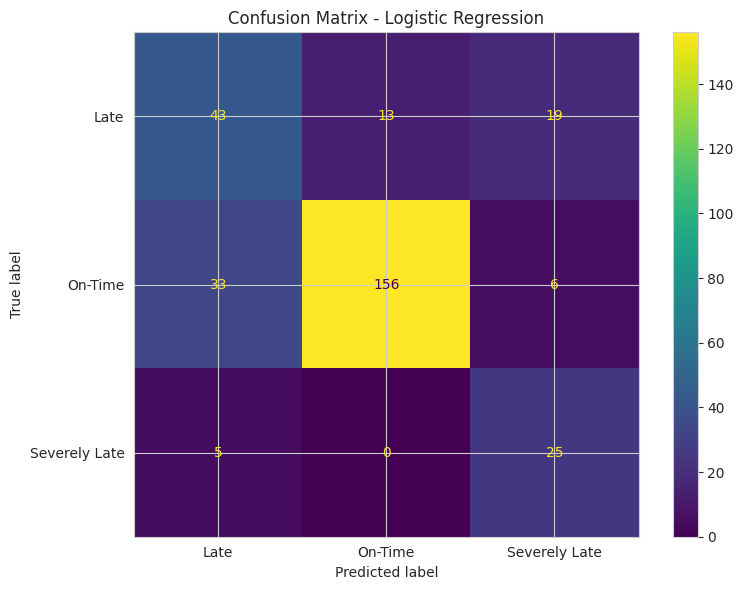

In [40]:
# ============================================================
# 7.2 Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Get the class labels in the model's order
class_labels = selected_pipe.classes_

# Calculate confusion matrix
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=class_labels
)

# Display numerical confusion matrix
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {label}" for label in class_labels],
    columns=[f"Predicted: {label}" for label in class_labels]
)

print("Confusion Matrix:")
display(cm_df)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(f"Confusion Matrix - {selected_model_name}")
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# 7.3 Confusion Matrix Interpretation
# ============================================================

print("\nConfusion Matrix Interpretation")
print("=" * 50)

for i, class_name in enumerate(class_labels):
    actual_total = cm[i].sum()
    correct = cm[i, i]
    missed = actual_total - correct
    recall = correct / actual_total if actual_total > 0 else 0

    print(f"\nClass: {class_name}")
    print(f"Actual cases: {actual_total}")
    print(f"Correctly classified: {correct}")
    print(f"Misclassified: {missed}")
    print(f"Class recall: {recall:.3f}")

# Explicit minority-class analysis
minority_class = "Severely Late"
minority_index = list(class_labels).index(minority_class)

minority_actual = cm[minority_index].sum()
minority_correct = cm[minority_index, minority_index]
minority_missed = minority_actual - minority_correct
minority_recall = (
    minority_correct / minority_actual
    if minority_actual > 0 else 0
)

print("\n" + "=" * 50)
print("MINORITY CLASS ANALYSIS")
print("=" * 50)
print(f"Minority class: {minority_class}")
print(f"Actual {minority_class} cases: {minority_actual}")
print(f"Correctly identified: {minority_correct}")
print(f"Missed: {minority_missed}")
print(f"Recall: {minority_recall:.3f}")

# Show where the minority class was misclassified
print("\nMisclassifications for Severely Late:")

for j, predicted_class in enumerate(class_labels):
    if j != minority_index and cm[minority_index, j] > 0:
        print(
            f"  {cm[minority_index, j]} were predicted as "
            f"{predicted_class}"
        )


Confusion Matrix Interpretation

Class: Late
Actual cases: 75
Correctly classified: 43
Misclassified: 32
Class recall: 0.573

Class: On-Time
Actual cases: 195
Correctly classified: 156
Misclassified: 39
Class recall: 0.800

Class: Severely Late
Actual cases: 30
Correctly classified: 25
Misclassified: 5
Class recall: 0.833

MINORITY CLASS ANALYSIS
Minority class: Severely Late
Actual Severely Late cases: 30
Correctly identified: 25
Missed: 5
Recall: 0.833

Misclassifications for Severely Late:
  5 were predicted as Late


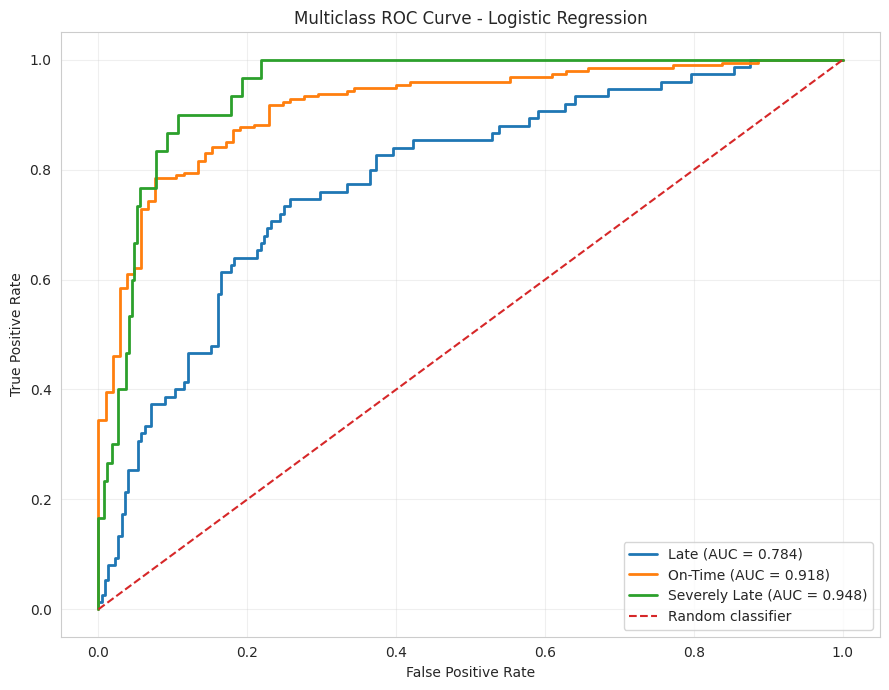

ROC-AUC Results
Late: 0.784
On-Time: 0.918
Severely Late: 0.948

Macro-average ROC-AUC: 0.883


In [42]:
# ============================================================
# 7.4 Multiclass ROC Curve
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get predicted probabilities
y_test_proba = selected_pipe.predict_proba(X_test_sel)

# Convert the multiclass target into one-vs-rest binary form
y_test_bin = label_binarize(
    y_test,
    classes=class_labels
)

plt.figure(figsize=(9, 7))

roc_auc_values = {}

for i, class_name in enumerate(class_labels):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_test_proba[:, i]
    )

    class_auc = auc(fpr, tpr)
    roc_auc_values[class_name] = class_auc

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Multiclass ROC Curve - {selected_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Macro-average ROC-AUC
macro_roc_auc = roc_auc_score(
    y_test,
    y_test_proba,
    multi_class="ovr",
    average="macro"
)

print("ROC-AUC Results")
print("=" * 40)

for class_name, value in roc_auc_values.items():
    print(f"{class_name}: {value:.3f}")

print(f"\nMacro-average ROC-AUC: {macro_roc_auc:.3f}")

In [43]:
# ============================================================
# 7.5 ROC Curve Interpretation
# ============================================================

print("\nROC Curve Interpretation")
print("=" * 50)

best_roc_class = max(
    roc_auc_values,
    key=roc_auc_values.get
)

worst_roc_class = min(
    roc_auc_values,
    key=roc_auc_values.get
)

print(
    f"The highest class-specific ROC-AUC is for "
    f"{best_roc_class}: {roc_auc_values[best_roc_class]:.3f}."
)

print(
    f"The lowest class-specific ROC-AUC is for "
    f"{worst_roc_class}: {roc_auc_values[worst_roc_class]:.3f}."
)

print(
    f"The macro-average ROC-AUC is "
    f"{macro_roc_auc:.3f}, representing the average "
    f"one-vs-rest discrimination across the three classes."
)

print(
    f"For the minority class, Severely Late, the ROC-AUC is "
    f"{roc_auc_values['Severely Late']:.3f}."
)

print(
    "A higher ROC-AUC indicates that the model is better at "
    "distinguishing that class from the other classes."
)


ROC Curve Interpretation
The highest class-specific ROC-AUC is for Severely Late: 0.948.
The lowest class-specific ROC-AUC is for Late: 0.784.
The macro-average ROC-AUC is 0.883, representing the average one-vs-rest discrimination across the three classes.
For the minority class, Severely Late, the ROC-AUC is 0.948.
A higher ROC-AUC indicates that the model is better at distinguishing that class from the other classes.


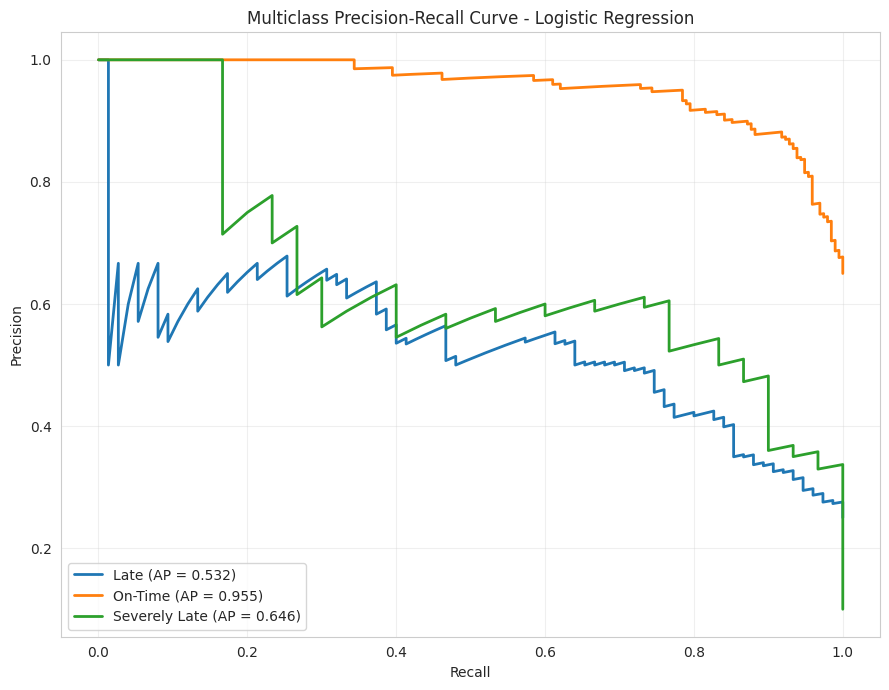

Precision-Recall Results
Late: 0.532
On-Time: 0.955
Severely Late: 0.646

Macro-average PR-AUC: 0.711


In [44]:
# ============================================================
# 7.6 Multiclass Precision-Recall Curve
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(9, 7))

pr_auc_values = {}

for i, class_name in enumerate(class_labels):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_test_proba[:, i]
    )

    average_precision = average_precision_score(
        y_test_bin[:, i],
        y_test_proba[:, i]
    )

    pr_auc_values[class_name] = average_precision

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{class_name} (AP = {average_precision:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Multiclass Precision-Recall Curve - {selected_model_name}"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

macro_pr_auc = np.mean(list(pr_auc_values.values()))

print("Precision-Recall Results")
print("=" * 40)

for class_name, value in pr_auc_values.items():
    print(f"{class_name}: {value:.3f}")

print(f"\nMacro-average PR-AUC: {macro_pr_auc:.3f}")

In [45]:
# ============================================================
# 7.7 Precision-Recall Interpretation
# ============================================================

print("\nPrecision-Recall Curve Interpretation")
print("=" * 50)

print(
    f"On-Time average precision: "
    f"{pr_auc_values['On-Time']:.3f}"
)

print(
    f"Late average precision: "
    f"{pr_auc_values['Late']:.3f}"
)

print(
    f"Severely Late average precision: "
    f"{pr_auc_values['Severely Late']:.3f}"
)

print(
    f"Macro-average PR-AUC: "
    f"{macro_pr_auc:.3f}"
)

print(
    "\nSeverely Late is the minority class and represents "
    "10% of the dataset."
)

print(
    "For a PR curve, the baseline precision for the "
    "Severely Late one-vs-rest problem is approximately "
    "0.10 because Severely Late represents 10% of the test data."
)

if pr_auc_values["Severely Late"] > 0.10:
    print(
        f"The Severely Late average precision "
        f"({pr_auc_values['Severely Late']:.3f}) is above "
        f"the 10% prevalence baseline, indicating useful "
        f"minority-class discrimination."
    )
else:
    print(
        f"The Severely Late average precision "
        f"({pr_auc_values['Severely Late']:.3f}) is close to "
        f"or below the 10% prevalence baseline, indicating "
        f"limited minority-class precision-recall performance."
    )


Precision-Recall Curve Interpretation
On-Time average precision: 0.955
Late average precision: 0.532
Severely Late average precision: 0.646
Macro-average PR-AUC: 0.711

Severely Late is the minority class and represents 10% of the dataset.
For a PR curve, the baseline precision for the Severely Late one-vs-rest problem is approximately 0.10 because Severely Late represents 10% of the test data.
The Severely Late average precision (0.646) is above the 10% prevalence baseline, indicating useful minority-class discrimination.


In [46]:
print("""
SECTION 7: DIAGNOSTICS EXPLANATION
==================================

The diagnostics section evaluated the selected classification model
using the held-out test set.

A confusion matrix was used to examine correct and incorrect
predictions for the On-Time, Late, and Severely Late categories.
This helps identify which payment-risk categories are being
classified correctly and where the model makes mistakes.

The Severely Late category received particular attention because it
is the minority class, representing approximately 10% of the data.
This is important because a model can achieve reasonable overall
accuracy while still performing poorly on a minority class.

A multiclass ROC curve was generated using a one-vs-rest approach.
The ROC-AUC values measure how well the model distinguishes each
payment-risk category from the other categories.

A Precision-Recall curve was also generated. This is particularly
useful for the imbalanced dataset because it shows the trade-off
between precision and recall for each class. The Severely Late
class was compared against its approximately 10% prevalence
baseline.

Together, the confusion matrix, ROC curve, and Precision-Recall
curve provide a more complete evaluation of the selected model
than accuracy alone. They show not only whether the model is
correct, but also how well it handles each payment-risk category,
especially the minority Severely Late category.
""")


SECTION 7: DIAGNOSTICS EXPLANATION

The diagnostics section evaluated the selected classification model
using the held-out test set.

A confusion matrix was used to examine correct and incorrect
predictions for the On-Time, Late, and Severely Late categories.
This helps identify which payment-risk categories are being
classified correctly and where the model makes mistakes.

The Severely Late category received particular attention because it
is the minority class, representing approximately 10% of the data.
This is important because a model can achieve reasonable overall
accuracy while still performing poorly on a minority class.

A multiclass ROC curve was generated using a one-vs-rest approach.
The ROC-AUC values measure how well the model distinguishes each
payment-risk category from the other categories.

A Precision-Recall curve was also generated. This is particularly
useful for the imbalanced dataset because it shows the trade-off
between precision and recall for each class. Th

## 8. Evaluation of candidate models

In [47]:
# ============================================================
# 8.1 Evaluation Imports
# ============================================================

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [48]:
# ============================================================
# 8.2 Evaluate all candidate models on the held-out test set
# ============================================================

evaluation_results = []
fitted_candidate_models = {}

for model_name, model in candidate_models.items():

    # Create a fresh pipeline for each candidate model
    evaluation_pipe = ImbPipeline([
        ("preprocess", clone(preprocessor)),
        ("smote", SMOTE(random_state=42)),
        ("classifier", clone(model))
    ])

    # Fit on training data ONLY
    evaluation_pipe.fit(X_train_sel, y_train)

    # Predict the held-out test set
    y_pred = evaluation_pipe.predict(X_test_sel)

    # Calculate classification metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision_macro = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision (Macro)": precision_macro,
        "Recall (Macro)": recall_macro,
        "F1 (Macro)": f1_macro,
        "Precision (Weighted)": precision_weighted,
        "Recall (Weighted)": recall_weighted,
        "F1 (Weighted)": f1_weighted
    })

    fitted_candidate_models[model_name] = evaluation_pipe

# Convert results into a DataFrame
test_results_df = pd.DataFrame(evaluation_results)

# Sort by macro F1
test_results_df = test_results_df.sort_values(
    by="F1 (Macro)",
    ascending=False
).reset_index(drop=True)

print("Held-Out Test Set Evaluation")
print("=" * 70)

display(
    test_results_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision (Macro)": "{:.3f}",
        "Recall (Macro)": "{:.3f}",
        "F1 (Macro)": "{:.3f}",
        "Precision (Weighted)": "{:.3f}",
        "Recall (Weighted)": "{:.3f}",
        "F1 (Weighted)": "{:.3f}"
    })
)

Held-Out Test Set Evaluation


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),Precision (Weighted),Recall (Weighted),F1 (Weighted)
0,Logistic Regression,0.747,0.651,0.736,0.678,0.783,0.747,0.757
1,Support Vector Machine,0.737,0.632,0.658,0.643,0.753,0.737,0.743
2,Gradient Boosting,0.690,0.583,0.584,0.583,0.682,0.690,0.686
3,K-Nearest Neighbors,0.663,0.565,0.600,0.575,0.711,0.663,0.680
4,Random Forest,0.710,0.565,0.557,0.558,0.689,0.710,0.697
5,Decision Tree,0.657,0.541,0.576,0.554,0.668,0.657,0.661


In [49]:
# ============================================================
# 8.3 Detailed Classification Reports
# ============================================================

for model_name, evaluation_pipe in fitted_candidate_models.items():

    y_pred = evaluation_pipe.predict(X_test_sel)

    print("\n" + "=" * 75)
    print(f"{model_name} - TEST SET CLASSIFICATION REPORT")
    print("=" * 75)

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


Logistic Regression - TEST SET CLASSIFICATION REPORT
               precision    recall  f1-score   support

         Late       0.53      0.57      0.55        75
      On-Time       0.92      0.80      0.86       195
Severely Late       0.50      0.83      0.62        30

     accuracy                           0.75       300
    macro avg       0.65      0.74      0.68       300
 weighted avg       0.78      0.75      0.76       300


K-Nearest Neighbors - TEST SET CLASSIFICATION REPORT
               precision    recall  f1-score   support

         Late       0.41      0.53      0.47        75
      On-Time       0.87      0.73      0.80       195
Severely Late       0.41      0.53      0.46        30

     accuracy                           0.66       300
    macro avg       0.56      0.60      0.58       300
 weighted avg       0.71      0.66      0.68       300


Decision Tree - TEST SET CLASSIFICATION REPORT
               precision    recall  f1-score   support

         Lat

In [50]:
# ============================================================
# 8.4 Macro vs Weighted Metrics
# ============================================================

print("Macro vs Weighted Metrics")
print("=" * 60)

print(
    """
MACRO AVERAGE
-------------
Macro averaging gives each class equal importance.
Therefore, On-Time, Late and Severely Late contribute
equally to the final score.

This is important for this dataset because Severely Late
is the minority class.

WEIGHTED AVERAGE
----------------
Weighted averaging accounts for the number of observations
in each class.

Therefore, the large On-Time class has a greater influence
on the weighted score than the smaller Severely Late class.

Because the dataset is imbalanced, macro F1 and macro recall
are especially useful for checking whether the model performs
reasonably across all three classes rather than mainly
performing well on the majority class.
"""
)

Macro vs Weighted Metrics

MACRO AVERAGE
-------------
Macro averaging gives each class equal importance.
Therefore, On-Time, Late and Severely Late contribute
equally to the final score.

This is important for this dataset because Severely Late
is the minority class.

WEIGHTED AVERAGE
----------------
Weighted averaging accounts for the number of observations
in each class.

Therefore, the large On-Time class has a greater influence
on the weighted score than the smaller Severely Late class.

Because the dataset is imbalanced, macro F1 and macro recall
are especially useful for checking whether the model performs
reasonably across all three classes rather than mainly
performing well on the majority class.



In [51]:
# ============================================================
# 8.5 Identify best-performing models on the test set
# ============================================================

best_test_f1_model = test_results_df.loc[
    test_results_df["F1 (Macro)"].idxmax(),
    "Model"
]

best_test_recall_model = test_results_df.loc[
    test_results_df["Recall (Macro)"].idxmax(),
    "Model"
]

best_test_accuracy_model = test_results_df.loc[
    test_results_df["Accuracy"].idxmax(),
    "Model"
]

print("Best Test-Set Results")
print("=" * 50)

print(
    f"Highest Accuracy: {best_test_accuracy_model}"
)

print(
    f"Highest Macro Recall: {best_test_recall_model}"
)

print(
    f"Highest Macro F1: {best_test_f1_model}"
)

Best Test-Set Results
Highest Accuracy: Logistic Regression
Highest Macro Recall: Logistic Regression
Highest Macro F1: Logistic Regression


In [52]:
# ============================================================
# 8.6 Selected Model Performance
# ============================================================

selected_test_row = test_results_df[
    test_results_df["Model"] == selected_model_name
].iloc[0]

print("Selected Model Test Performance")
print("=" * 60)

print(f"Selected model: {selected_model_name}")
print(f"Accuracy: {selected_test_row['Accuracy']:.3f}")
print(
    f"Precision (Macro): "
    f"{selected_test_row['Precision (Macro)']:.3f}"
)
print(
    f"Recall (Macro): "
    f"{selected_test_row['Recall (Macro)']:.3f}"
)
print(
    f"F1 (Macro): "
    f"{selected_test_row['F1 (Macro)']:.3f}"
)
print(
    f"Precision (Weighted): "
    f"{selected_test_row['Precision (Weighted)']:.3f}"
)
print(
    f"Recall (Weighted): "
    f"{selected_test_row['Recall (Weighted)']:.3f}"
)
print(
    f"F1 (Weighted): "
    f"{selected_test_row['F1 (Weighted)']:.3f}"
)

Selected Model Test Performance
Selected model: Logistic Regression
Accuracy: 0.747
Precision (Macro): 0.651
Recall (Macro): 0.736
F1 (Macro): 0.678
Precision (Weighted): 0.783
Recall (Weighted): 0.747
F1 (Weighted): 0.757


In [53]:
# ============================================================
# 8.7 Minority-Class Recall Comparison
# ============================================================

minority_class = "Severely Late"

minority_results = []

for model_name, evaluation_pipe in fitted_candidate_models.items():

    y_pred = evaluation_pipe.predict(X_test_sel)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    minority_results.append({
        "Model": model_name,
        "Severely Late Precision":
            report[minority_class]["precision"],
        "Severely Late Recall":
            report[minority_class]["recall"],
        "Severely Late F1":
            report[minority_class]["f1-score"],
        "Severely Late Support":
            int(report[minority_class]["support"])
    })

minority_results_df = pd.DataFrame(
    minority_results
).sort_values(
    by="Severely Late Recall",
    ascending=False
).reset_index(drop=True)

display(
    minority_results_df.style.format({
        "Severely Late Precision": "{:.3f}",
        "Severely Late Recall": "{:.3f}",
        "Severely Late F1": "{:.3f}",
        "Severely Late Support": "{:.0f}"
    })
)

,Model,Severely Late Precision,Severely Late Recall,Severely Late F1,Severely Late Support
0,Logistic Regression,0.500,0.833,0.625,30
1,Decision Tree,0.415,0.567,0.479,30
2,Support Vector Machine,0.486,0.567,0.523,30
3,K-Nearest Neighbors,0.410,0.533,0.464,30
4,Gradient Boosting,0.516,0.533,0.525,30
5,Random Forest,0.419,0.433,0.426,30


In [54]:
# ============================================================
# 8.8 Final Model Selection Explanation
# ============================================================

cv_selected_model = results_df.iloc[0]["model"]
cv_selected_f1 = results_df.iloc[0]["f1_macro_mean"]

print("FINAL MODEL SELECTION")
print("=" * 70)

print(f"Model selected during cross-validation: {cv_selected_model}")
print(f"Cross-validation macro F1: {cv_selected_f1:.3f}")

print(
    """
The candidate model was selected using cross-validation on the
training data rather than using the held-out test set. This
prevents the test set from influencing model selection.

Macro F1 was emphasized because the payment risk target is
imbalanced, with Severely Late representing the minority class.

The held-out test set was then used only to provide an unbiased
evaluation of the candidate models after training.

The selected model should therefore remain the model chosen
through cross-validation, even if another model happens to have
a slightly higher score on this particular test split.
"""
)

selected_test_f1 = test_results_df.loc[
    test_results_df["Model"] == cv_selected_model,
    "F1 (Macro)"
].iloc[0]

selected_test_recall = test_results_df.loc[
    test_results_df["Model"] == cv_selected_model,
    "Recall (Macro)"
].iloc[0]

print(
    f"\nHeld-out test macro F1 for {cv_selected_model}: "
    f"{selected_test_f1:.3f}"
)

print(
    f"Held-out test macro recall for {cv_selected_model}: "
    f"{selected_test_recall:.3f}"
)

FINAL MODEL SELECTION
Model selected during cross-validation: Logistic Regression
Cross-validation macro F1: 0.626

The candidate model was selected using cross-validation on the
training data rather than using the held-out test set. This
prevents the test set from influencing model selection.

Macro F1 was emphasized because the payment risk target is
imbalanced, with Severely Late representing the minority class.

The held-out test set was then used only to provide an unbiased
evaluation of the candidate models after training.

The selected model should therefore remain the model chosen
through cross-validation, even if another model happens to have
a slightly higher score on this particular test split.


Held-out test macro F1 for Logistic Regression: 0.678
Held-out test macro recall for Logistic Regression: 0.736


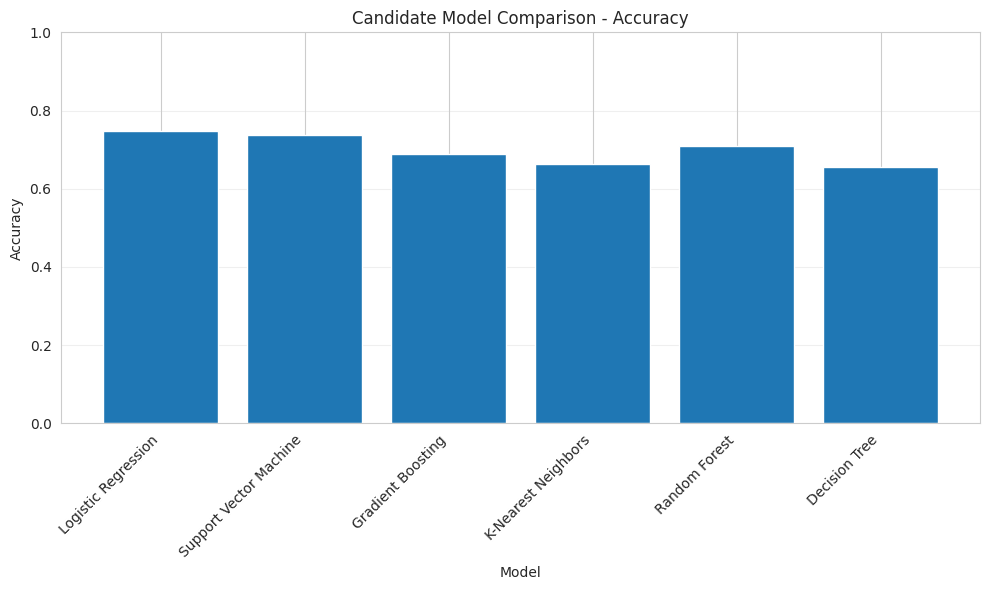

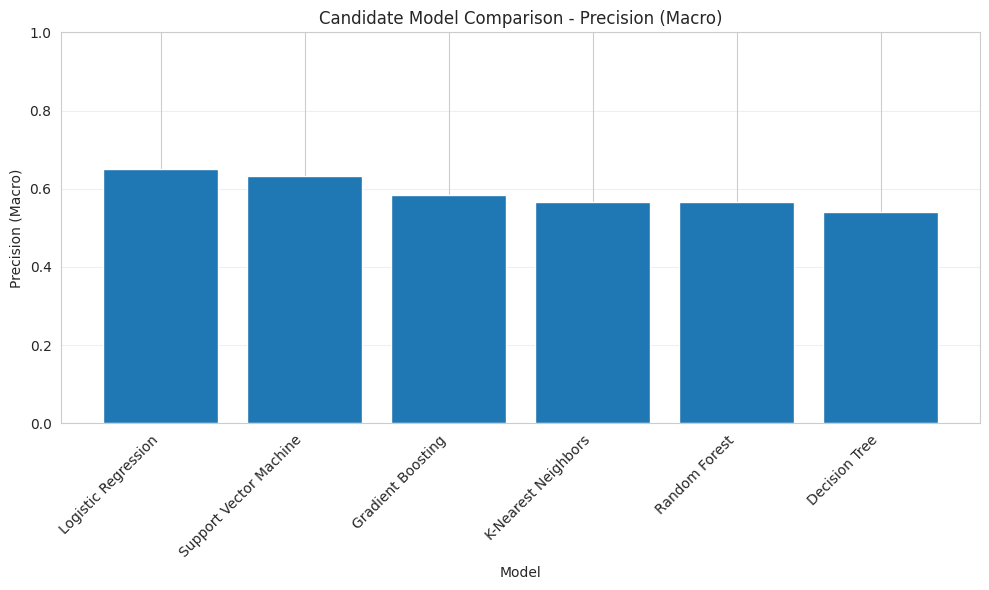

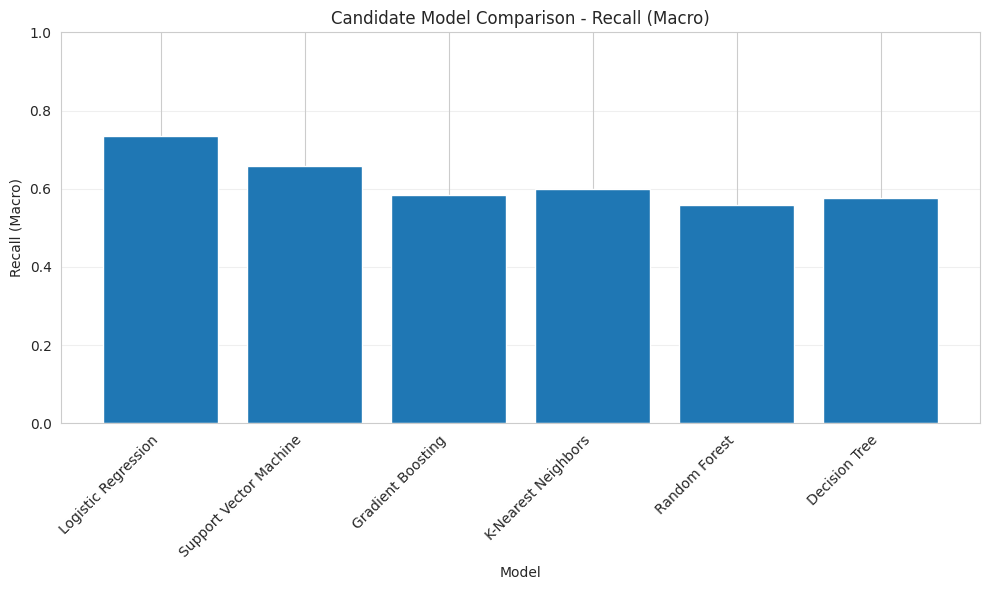

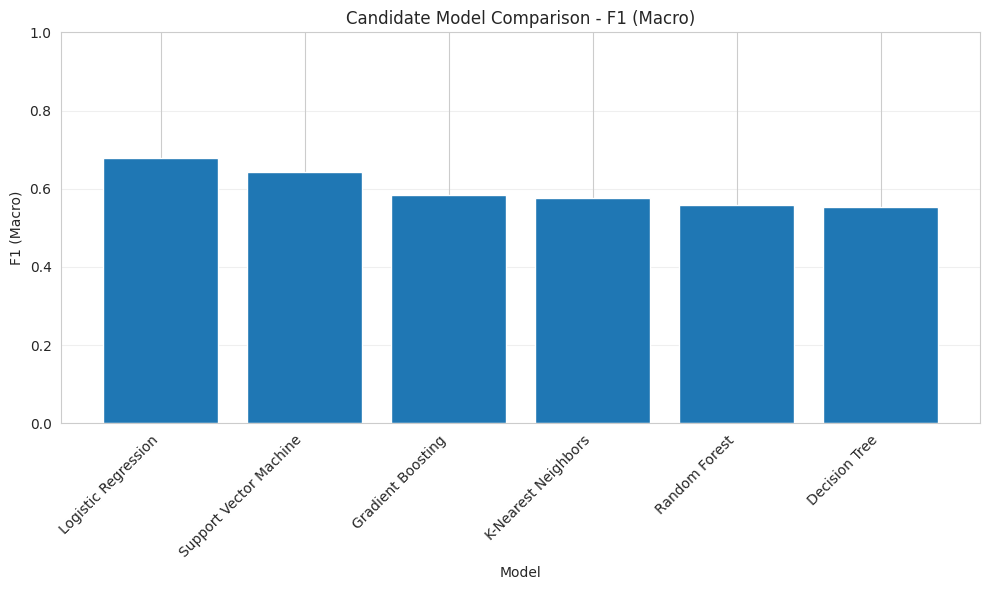

In [55]:
# ============================================================
# 8.9 Compare Candidate Models
# ============================================================

metrics_to_plot = [
    "Accuracy",
    "Precision (Macro)",
    "Recall (Macro)",
    "F1 (Macro)"
]

for metric in metrics_to_plot:

    plt.figure(figsize=(10, 6))

    plt.bar(
        test_results_df["Model"],
        test_results_df[metric]
    )

    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.title(f"Candidate Model Comparison - {metric}")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [56]:
print("""
SECTION 8: EVALUATION OF CANDIDATE MODELS
=========================================

All six candidate classification models were evaluated on the
held-out test set:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. Support Vector Machine

Each model was trained using the same preprocessing and SMOTE
pipeline. SMOTE was applied within the pipeline so that synthetic
samples were generated only from the training data and did not
cause information leakage into the test set.

The models were compared using several metrics, including accuracy,
macro precision, macro recall, macro F1-score, weighted precision,
weighted recall, and weighted F1-score.

Macro averaging gives equal importance to all three payment-risk
categories. This is particularly important because the dataset is
imbalanced, with On-Time as the majority class and Severely Late as
the minority class.

Weighted averaging takes class size into account. Consequently, the
large On-Time class has a greater influence on weighted metrics.
Comparing macro and weighted metrics therefore helps determine
whether a model is performing well across all classes or mainly on
the majority class.

Detailed classification reports were produced for every candidate
model. The Severely Late class was examined separately because
correctly identifying minority-class invoices is an important part
of the payment-risk prediction problem.

Model selection was based on cross-validation results from the
training data rather than on the held-out test set. This prevents
the test set from influencing model selection and provides a more
reliable estimate of generalization performance.

The selected model was Logistic Regression because it achieved the
best cross-validation macro F1-score among the candidate models and
showed stronger recall for the minority Severely Late class compared
with the Random Forest model considered during selection.

The held-out test set was then used only for final evaluation and
comparison of the candidate models.
""")


SECTION 8: EVALUATION OF CANDIDATE MODELS

All six candidate classification models were evaluated on the
held-out test set:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. Support Vector Machine

Each model was trained using the same preprocessing and SMOTE
pipeline. SMOTE was applied within the pipeline so that synthetic
samples were generated only from the training data and did not
cause information leakage into the test set.

The models were compared using several metrics, including accuracy,
macro precision, macro recall, macro F1-score, weighted precision,
weighted recall, and weighted F1-score.

Macro averaging gives equal importance to all three payment-risk
categories. This is particularly important because the dataset is
imbalanced, with On-Time as the majority class and Severely Late as
the minority class.

Weighted averaging takes class size into account. Consequently, the
large On-Time class has a greater influence o

In [57]:
print("""
PERSON 4 CONCLUSION
===================

The diagnostics and evaluation results provide a comprehensive
assessment of the classification models beyond simple accuracy.

The confusion matrix identifies the types of classification errors
made by the selected model. The ROC analysis evaluates the model's
ability to distinguish between the three payment-risk categories,
while the Precision-Recall analysis provides additional insight
into performance under the imbalanced class distribution.

The evaluation of all candidate models on the held-out test set
allows their performance to be compared using multiple metrics.
Macro-averaged metrics are especially important because they give
equal importance to the minority Severely Late class.

The model selection decision was based on cross-validation performed
on the training data. Logistic Regression was selected because it
achieved the strongest macro F1 performance during cross-validation
and provided better minority-class recall than the Random Forest
model considered during selection.

Therefore, the combination of cross-validation, held-out test
evaluation, confusion-matrix analysis, ROC analysis, and
Precision-Recall analysis provides a robust assessment of the
invoice payment risk classification task.
""")


PERSON 4 CONCLUSION

The diagnostics and evaluation results provide a comprehensive
assessment of the classification models beyond simple accuracy.

The confusion matrix identifies the types of classification errors
made by the selected model. The ROC analysis evaluates the model's
ability to distinguish between the three payment-risk categories,
while the Precision-Recall analysis provides additional insight
into performance under the imbalanced class distribution.

The evaluation of all candidate models on the held-out test set
allows their performance to be compared using multiple metrics.
Macro-averaged metrics are especially important because they give
equal importance to the minority Severely Late class.

The model selection decision was based on cross-validation performed
on the training data. Logistic Regression was selected because it
achieved the strongest macro F1 performance during cross-validation
and provided better minority-class recall than the Random Forest
model cons

## 9. Hyperparameter tuning

## 9.1 GridSearch Setup

In [58]:
from sklearn.model_selection import GridSearchCV
import warnings

# Test with several values
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
}

tune_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=5000, solver='saga', random_state=42))
])

grid_search = GridSearchCV(tune_pipe, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True)

In [59]:
print(f"""
Section 9.1 tunes Logistic Regression model selected in section 6.4.
12 combinations of C and penalty type are searched with GridSearchCV and evaluated using the same
stratified 5-fold Cross Validation scheme and the same f1_macro scoring used to pick the model in the first place.
""")


Section 9.1 tunes Logistic Regression model selected in section 6.4.
12 combinations of C and penalty type are searched with GridSearchCV and evaluated using the same
stratified 5-fold Cross Validation scheme and the same f1_macro scoring used to pick the model in the first place.



## 9.2 Carry out the search and inspect the best parameters

In [60]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    grid_search.fit(X_train_sel, y_train)

best_pipe = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)
print(f"Best cross-validated f1_macro: {grid_search.best_score_:.4f}")


Best hyperparameters: {'classifier__C': 10, 'classifier__penalty': 'l1'}
Best cross-validated f1_macro: 0.6298


In [61]:
print(f"""
The best hyperparameters found are:'classifier__C': 10, 'classifier__penalty': 'l1', which reaches a cross-validated f1_macro score of 0.6298
compared to 0.6258 for the untuned Logistic Regression model in section 6.2.
""")


The best hyperparameters found are:'classifier__C': 10, 'classifier__penalty': 'l1', which reaches a cross-validated f1_macro score of 0.6298
compared to 0.6258 for the untuned Logistic Regression model in section 6.2.



## 9.3 Tuned vs Untuned Perfomance

In [62]:
untuned_row = results_df[results_df['model'] == selected_model_name].iloc[0]

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    tuned_scores = cross_validate(best_pipe, X_train_sel, y_train, cv=cv, scoring=scoring, n_jobs=-1)

comparison_df = pd.DataFrame({
    'metric': scoring,
    'untuned': [untuned_row[f'{m}_mean'] for m in scoring],
    'tuned': [tuned_scores[f'test_{m}'].mean() for m in scoring],
})
comparison_df['change'] = comparison_df['tuned'] - comparison_df['untuned']
comparison_df.round(4)

,metric,untuned,tuned,change
0,accuracy,0.6983,0.7017,0.0033
1,f1_macro,0.6258,0.6298,0.0041
2,f1_weighted,0.7112,0.7149,0.0037
3,precision_macro,0.6067,0.6106,0.0039
4,recall_macro,0.6716,0.6761,0.0044


In [63]:
print(f"""
Tuning changed f1_macro from 0.6258 to 0.6298, a change of 0.004.
This is a small improvement, meaning that Logistic Regression was a good perfoming model even before tuning.
""")


Tuning changed f1_macro from 0.6258 to 0.6298, a change of 0.004.
This is a small improvement, meaning that Logistic Regression was a good perfoming model even before tuning.



## 9.4 Finding out if tuning helps in catching the Severely Late Invoices

In [64]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    tuned_preds = cross_val_predict(best_pipe, X_train_sel, y_train, cv=cv)

tuned_report = classification_report(y_train, tuned_preds, output_dict=True)
print(classification_report(y_train, tuned_preds, digits=3))

               precision    recall  f1-score   support

         Late      0.460     0.533     0.494       300
      On-Time      0.895     0.762     0.823       780
Severely Late      0.468     0.733     0.571       120

     accuracy                          0.702      1200
    macro avg      0.607     0.676     0.629      1200
 weighted avg      0.743     0.702     0.715      1200



In [65]:
print(f"""
Out of the 120 invoices that are Severely Late, this tuned model correctly flags about 73.3% of them
which is the same recall score for the untuned Logistic Regression model in section 6.4.

Tuning improved the f1 macro score but recall on Severely Late stayed exactly the same for the
tuned model as it was for the untuned model.
""")


Out of the 120 invoices that are Severely Late, this tuned model correctly flags about 73.3% of them
which is the same recall score for the untuned Logistic Regression model in section 6.4.

Tuning improved the f1 macro score but recall on Severely Late stayed exactly the same for the
tuned model as it was for the untuned model.



## 10. Explainability

Logistic Regression Coefficients

In [66]:
final_pipeline = best_pipe

classifier = final_pipeline.named_steps["classifier"]
preprocess = final_pipeline.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

print("Selected model:", type(classifier).__name__)
print("Classes:", classifier.classes_)
print("Number of transformed features:", len(feature_names))

coefficient_df = pd.DataFrame(
    classifier.coef_,
    index=classifier.classes_,
    columns=feature_names
)

coefficient_df

Selected model: LogisticRegression
Classes: ['Late' 'On-Time' 'Severely Late']
Number of transformed features: 17


,num_general__payment_terms_days,num_general__prior_late_payments_count,num_general__discount_offered_pct,num_general__days_outstanding_avg_historical,num_general__economic_sector_growth_rate_pct,num_skewed__invoice_amount_kes,cat_nominal__client_industry_Construction,cat_nominal__client_industry_Healthcare,cat_nominal__client_industry_Manufacturing,cat_nominal__client_industry_Retail,cat_nominal__client_industry_Technology,cat_nominal__payment_method_Bank Transfer,cat_nominal__payment_method_Cheque,cat_nominal__payment_method_Letter of Credit,cat_nominal__payment_method_Mobile Money,cat_nominal__has_dispute_history_Yes,cat_ordinal__client_credit_rating
Late,0.000000,0.000000,0.096646,0.000000,-0.127691,-0.056535,0.000000,0.022714,-0.205009,0.000000,0.000000,-0.198369,0.022137,0.000000,0.0,0.000000,0.000000
On-Time,-1.119154,-0.857502,0.000000,-0.205864,0.000000,0.000000,-1.237683,0.000000,0.000052,-0.420852,0.672448,0.139536,0.000000,-0.115221,0.0,-1.513915,1.497046
Severely Late,1.762255,0.716179,-0.157419,0.444126,0.030449,0.189385,1.655039,-0.520957,0.000000,0.145896,-1.818215,0.000000,-0.083907,0.774384,0.0,2.397939,-1.994951


In [67]:
for class_name in classifier.classes_:
    class_coefficients = coefficient_df.loc[class_name].sort_values()

    print(f"\n{'=' * 70}")
    print(f"Class: {class_name}")
    print(f"{'=' * 70}")

    print("\nFeatures with the most negative coefficients:")
    display(class_coefficients.head(5).to_frame("coefficient"))

    print("\nFeatures with the most positive coefficients:")
    display(class_coefficients.tail(5).sort_values(ascending=False).to_frame("coefficient"))


Class: Late

Features with the most negative coefficients:


,coefficient
cat_nominal__client_industry_Manufacturing,-0.205009
cat_nominal__payment_method_Bank Transfer,-0.198369
num_general__economic_sector_growth_rate_pct,-0.127691
num_skewed__invoice_amount_kes,-0.056535
cat_nominal__client_industry_Construction,0.000000



Features with the most positive coefficients:


,coefficient
num_general__discount_offered_pct,0.096646
cat_nominal__client_industry_Healthcare,0.022714
cat_nominal__payment_method_Cheque,0.022137
cat_nominal__has_dispute_history_Yes,0.000000
cat_ordinal__client_credit_rating,0.000000



Class: On-Time

Features with the most negative coefficients:


...

,coefficient
cat_ordinal__client_credit_rating,1.497046
cat_nominal__client_industry_Technology,0.672448
cat_nominal__payment_method_Bank Transfer,0.139536
cat_nominal__client_industry_Manufacturing,0.000052
cat_nominal__payment_method_Mobile Money,0.000000



Class: Severely Late

Features with the most negative coefficients:


,coefficient
cat_ordinal__client_credit_rating,-1.994951
cat_nominal__client_industry_Technology,-1.818215
cat_nominal__client_industry_Healthcare,-0.520957
num_general__discount_offered_pct,-0.157419
cat_nominal__payment_method_Cheque,-0.083907



Features with the most positive coefficients:


,coefficient
cat_nominal__has_dispute_history_Yes,2.397939
num_general__payment_terms_days,1.762255
cat_nominal__client_industry_Construction,1.655039
cat_nominal__payment_method_Letter of Credit,0.774384
num_general__prior_late_payments_count,0.716179


SHAPNExplainability

In [68]:
import shap
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# Use the already-fitted tuned pipeline
final_pipeline = best_pipe

preprocess = final_pipeline.named_steps["preprocess"]
classifier = final_pipeline.named_steps["classifier"]

# Transform the held-out test set using the fitted preprocessing stage
X_test_transformed = preprocess.transform(X_test_sel)

feature_names = preprocess.get_feature_names_out()

print("Model being explained:", type(classifier).__name__)
print("Classes:", classifier.classes_)

# SHAP can explain the model's predicted probabilities.
# We use a smaller background sample to keep computation manageable.

X_train_transformed = preprocess.transform(X_train_sel)

background = shap.sample(
    X_train_transformed,
    100,
    random_state=RANDOM_STATE
)

explainer = shap.Explainer(
    classifier.predict_proba,
    background,
    feature_names=feature_names,
    output_names=list(classifier.classes_)
)

# Explain a manageable subset of the test set
X_test_shap = X_test_transformed[:100]

shap_explanation = explainer(X_test_shap)

print("SHAP explanation generated successfully.")
print("Explained classes:", classifier.classes_)

Model being explained: LogisticRegression
Classes: ['Late' 'On-Time' 'Severely Late']


PermutationExplainer explainer: 101it [00:26,  3.71it/s]                         

SHAP explanation generated successfully.
Explained classes: ['Late' 'On-Time' 'Severely Late']


,feature,mean_abs_shap
16,cat_ordinal__client_credit_rating,0.135172
0,num_general__payment_terms_days,0.106557
1,num_general__prior_late_payments_count,0.064730
15,cat_nominal__has_dispute_history_Yes,0.051707
6,cat_nominal__client_industry_Construction,0.039022
10,cat_nominal__client_industry_Technology,0.023561
3,num_general__days_outstanding_avg_historical,0.019091
11,cat_nominal__payment_method_Bank Transfer,0.014884
9,cat_nominal__client_industry_Retail,0.013953
4,num_general__economic_sector_growth_rate_pct,0.012407


/tmp/ipykernel_1207/2078294530.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


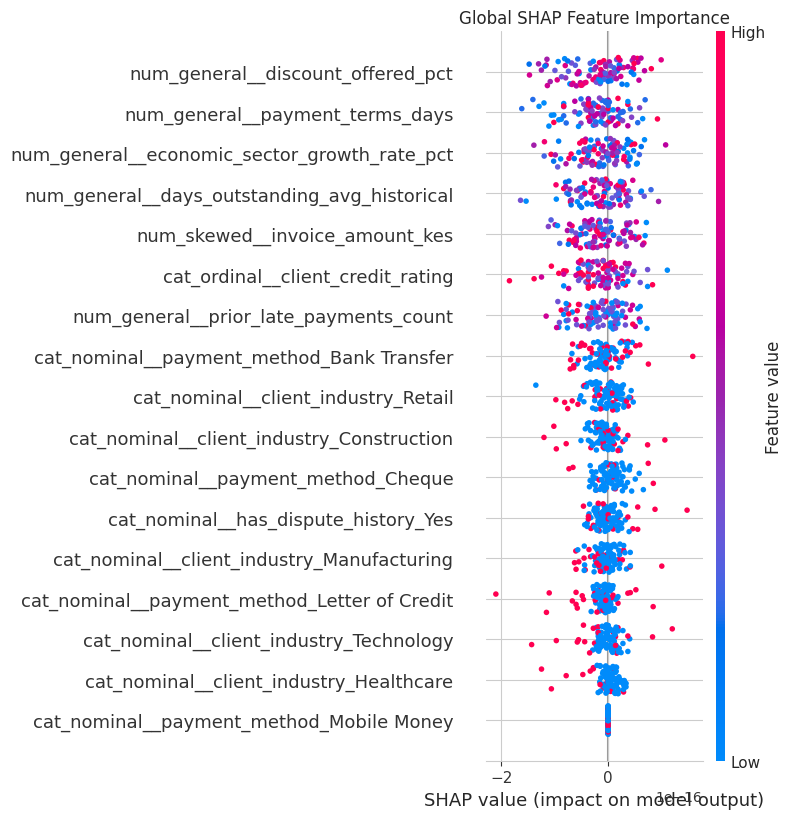

In [69]:
# Global SHAP importance across all three payment-risk classes

mean_abs_shap = np.abs(shap_explanation.values).mean(axis=(0, 2))

shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
)

display(shap_importance.head(15))

plt.figure(figsize=(9, 7))

shap.summary_plot(
    shap_explanation.values.mean(axis=2),
    X_test_shap,
    feature_names=feature_names,
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

Severely Late class index: 2


/tmp/ipykernel_1207/3539635026.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


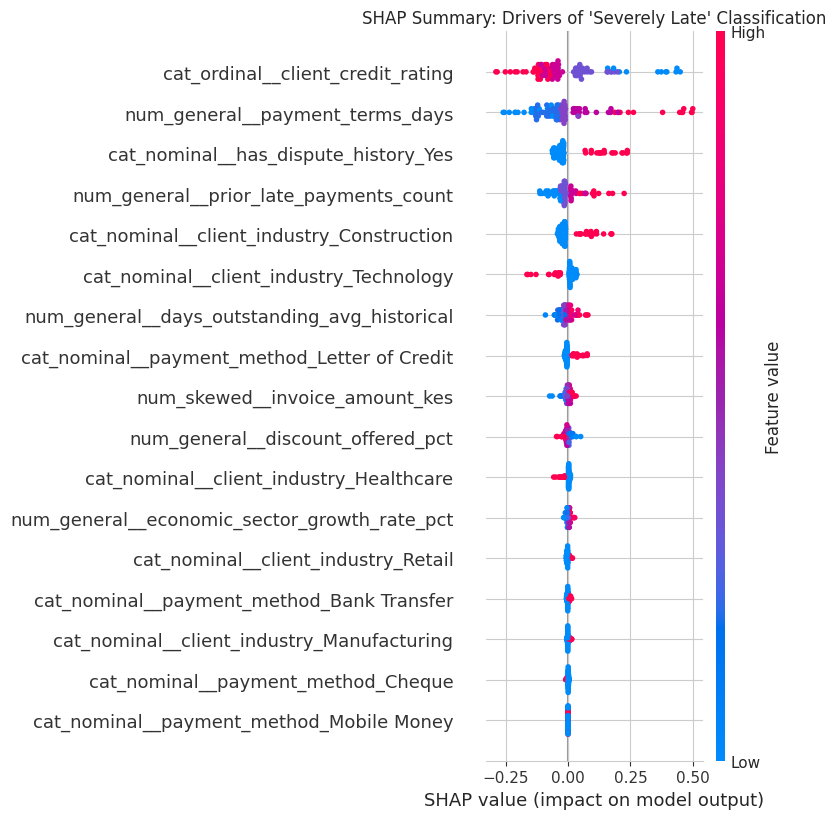

In [70]:
# Identify the position of the Severely Late class
severely_late_index = list(classifier.classes_).index("Severely Late")

print("Severely Late class index:", severely_late_index)

# SHAP values for Severely Late predictions

severely_late_shap_values = shap_explanation.values[:, :, severely_late_index]

shap.summary_plot(
    severely_late_shap_values,
    X_test_shap,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary: Drivers of 'Severely Late' Classification")
plt.tight_layout()
plt.show()

Putting the coefficient and SHAP results together, the model relies on the features in this order:

1. Client credit rating

This is the most important feature overall according to SHAP.

2. Payment terms

This is the second most important feature overall and has a strong positive relationship with Severely Late.

3. Previous late payments

Past payment behaviour is also highly influential.

4. Dispute history

Having a dispute history is particularly influential for distinguishing Severely Late from safer categories.

5. Industry

Construction and Technology have noticeable effects, although their influence is lower than the main financial/payment-behaviour variables.

LIME

In [71]:
import shap
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# Use the already-fitted tuned pipeline
final_pipeline = best_pipe

preprocess = final_pipeline.named_steps["preprocess"]
classifier = final_pipeline.named_steps["classifier"]

# Transform the held-out test set using the fitted preprocessing stage
X_test_transformed = preprocess.transform(X_test_sel)

feature_names = preprocess.get_feature_names_out()

print("Model being explained:", type(classifier).__name__)
print("Classes:", classifier.classes_)

# SHAP can explain the model's predicted probabilities.
# We use a smaller background sample to keep computation manageable.

X_train_transformed = preprocess.transform(X_train_sel)

background = shap.sample(
    X_train_transformed,
    100,
    random_state=RANDOM_STATE
)

explainer = shap.Explainer(
    classifier.predict_proba,
    background,
    feature_names=feature_names,
    output_names=list(classifier.classes_)
)

# Explain a manageable subset of the test set
X_test_shap = X_test_transformed[:100]

shap_explanation = explainer(X_test_shap)

print("SHAP explanation generated successfully.")
print("Explained classes:", classifier.classes_)

Model being explained: LogisticRegression
Classes: ['Late' 'On-Time' 'Severely Late']
SHAP explanation generated successfully.
Explained classes: ['Late' 'On-Time' 'Severely Late']


In [72]:
pip install lime

In [74]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=list(feature_names),
    class_names=list(classifier.classes_),
    mode="classification",
    random_state=RANDOM_STATE
)

target_index = X_test_sel.index[0]

position = X_test_sel.index.get_loc(target_index)
sample_instance = X_test_transformed[position]

lime_explanation = lime_explainer.explain_instance(
    sample_instance,
    classifier.predict_proba,
    num_features=8
)

predicted_class = classifier.predict(
    X_test_transformed[position:position + 1]
)[0]

actual_class = y_test.loc[target_index]

print(f"Test invoice index: {target_index}")
print(f"Actual payment-risk category: {actual_class}")
print(f"Predicted payment-risk category: {predicted_class}")

print("\nLIME explanation:")
for feature, weight in lime_explanation.as_list():
    print(f"  {feature:65s} {weight:+.4f}")

Test invoice index: 589
Actual payment-risk category: On-Time
Predicted payment-risk category: On-Time

LIME explanation:
  num_general__payment_terms_days <= -0.55                          +0.2732
  cat_nominal__has_dispute_history_Yes <= 0.00                      +0.2348
  cat_nominal__client_industry_Construction <= 0.00                 +0.1950
  1.00 < cat_ordinal__client_credit_rating <= 2.00                  +0.1714
  cat_nominal__client_industry_Technology > 0.00                    +0.0963
  -1.06 < num_general__prior_late_payments_count <= -0.09           +0.0821
  cat_nominal__client_industry_Retail <= 0.00                       +0.0691
  num_general__days_outstanding_avg_historical <= -0.71             +0.0523


## 11. Model persistence

In [75]:
## 11. Model Persistence

import joblib
import os

# GridSearchCV has already refitted the best estimator because refit=True.
final_pipeline = best_pipe

# Create model directory if it does not exist
model_dir = "./model"
os.makedirs(model_dir, exist_ok=True)

# Use a filename specific to this assignment
model_path = os.path.join(
    model_dir,
    "invoice_payment_risk_classifier.joblib"
)

# Save the complete pipeline
joblib.dump(final_pipeline, model_path)

print("Model persistence")
print("=" * 60)
print("Selected model:",
      type(final_pipeline.named_steps["classifier"]).__name__)
print("Saved pipeline:", model_path)
print("Pipeline saved successfully.")

Model persistence
Selected model: LogisticRegression
Saved pipeline: ./model/invoice_payment_risk_classifier.joblib
Pipeline saved successfully.


In [76]:
# Load the exact model that was just saved

loaded_pipeline = joblib.load(model_path)

print("Model loaded successfully.")
print("Loaded model:",
      type(loaded_pipeline.named_steps["classifier"]).__name__)

Model loaded successfully.
Loaded model: LogisticRegression


In [78]:
# Compare predictions from the original and loaded pipelines

original_predictions = final_pipeline.predict(X_test_sel)
loaded_predictions = loaded_pipeline.predict(X_test_sel)

predictions_match = np.array_equal(
    original_predictions,
    loaded_predictions
)

print("Original and loaded predictions identical:", predictions_match)

# Compare predicted probabilities

original_probabilities = final_pipeline.predict_proba(X_test_sel)
loaded_probabilities = loaded_pipeline.predict_proba(X_test_sel)

probabilities_match = np.allclose(
    original_probabilities,
    loaded_probabilities
)

print("Original and loaded probabilities identical:", probabilities_match)

# Demonstrate prediction using the persisted pipeline

sample_invoice = X_test_sel.iloc[[0]]

loaded_prediction = loaded_pipeline.predict(sample_invoice)[0]
loaded_probabilities = loaded_pipeline.predict_proba(sample_invoice)[0]

print("\nExample inference using the persisted model")
print("=" * 60)

print("Predicted payment-risk category:", loaded_prediction)

print("\nClass probabilities:")
for class_name, probability in zip(
    loaded_pipeline.named_steps["classifier"].classes_,
    loaded_probabilities
):
    print(f"  {class_name}: {probability:.3f}")

Original and loaded predictions identical: True
Original and loaded probabilities identical: True

Example inference using the persisted model
Predicted payment-risk category: On-Time

Class probabilities:
  Late: 0.042
  On-Time: 0.957
  Severely Late: 0.000


This section is basically a confirmation that the model was saved correctly and behaved exactly the same as the original. Hence it is reusable.

## 12. Conclusion & limitations

Conclusion

This project built a machine learning classification pipeline to predict invoice payment risk for three categories: On-Time Late and Severely Late. The analysis ran through a workflow that included exploratory data analysis, feature selection, data preprocessing, class-imbalance handling, model development, hyperparameter tuning, evaluation, explainability and model persistence.

The final tuned Logistic Regression model scored an accuracy of about 70.17% and a macro‑F1 score of, about 0.6298. The macro‑F1 score was useful because the dataset was imbalanced across the three payment‑risk categories. The preprocessing pipeline made sure that numerical variables and categorical variables were handled in the way and SMOTE helped fix the under‑representation of minority classes during training.

The explainability analysis gave insight into the Logistic Regression model’s predictions using Logistic Regression coefficients, SHAP and LIME. These methods showed that the model’s predictions can be looked at by both individual lenses, instead of being black boxes. The final pipeline was. Reloaded successfully showing that it can be reused for future invoice payment‑risk prediction tasks.

Limitations

The target variable is
imbalanced because On-Time invoices far outnumber Severely Late invoices. Although SMOTE was added to the modelling pipeline to give minority classes a chance during training synthetic oversampling does not add real‑world data. As a result performance on the minority class may still be less reliable than performance on the majority class.

The Late category has many fewer observations than the On-Time category. A bigger dataset with examples from each class could give more reliable estimates of model performance.

The ability of the model to work well in business settings depends on how well the dataset represents the people who will actually use the model. Differences in industries, economic conditions, client behaviour, payment policies and invoice practices may change how the model works when it is used on groups.

The final Logistic Regression model scored a macro‑F1 of about 0.6298. This shows that there is still room to make classification better across the three payment‑risk categories. Logistic Regression gives a decision boundary and might not capture complex nonlinear relationships between invoice and client characteristics.

